# Config A — Tabular RL (Q-Learning & SARSA)

Discrete state space: 716 states × 25 actions.  
Algorithms: Q-Learning, SARSA.

In [1]:
import sys, os
# Ensure project root is importable regardless of how this notebook was launched
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import optuna
from envs.env_setup import make_sepsis_env, N_STATES, N_ACTIONS
from agents.config_a.q_learning import QLearningAgent, QLearningConfig
from agents.config_a.sarsa import SARSAAgent, SARSAConfig
from utils.evaluation import eval_agent, print_results
from utils.plotting import plot_training_curve, plot_comparison

SEED = 42
np.random.seed(SEED)
print(f'States: {N_STATES}, Actions: {N_ACTIONS}')

States: 716, Actions: 25


## 1. Random Baseline

In [4]:
env = make_sepsis_env()
random_policy = lambda obs: env.action_space.sample()
random_results = eval_agent(random_policy, make_sepsis_env)
print_results('Random Baseline (Config A)', random_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== Random Baseline (Config A) ===
  Mean return  : 0.6245 ± 0.4499
  Survival rate: 72.8%
  Mean ep len  : 10.4


## 3. SARSA

In [ ]:
cfg_sarsa = SARSAConfig(
    alpha=0.1,
    gamma=0.5,
    epsilon_start=0.9,
    epsilon_end=0.01,
    epsilon_decay=3000,
    n_episodes=3000,
    alpha_decay='linear',   
    q_init=0.0             
)

sarsa_agent = SARSAAgent(N_STATES, N_ACTIONS, cfg_sarsa)

sarsa_returns = sarsa_agent.train(make_sepsis_env)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


In [ ]:
sarsa_results = eval_agent(sarsa_agent.get_policy(), make_sepsis_env)
print_results('SARSA (Config A)', sarsa_results)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
=== SARSA (Config A) ===
  Mean return  : 0.7208 ± 0.4339
  Survival rate: 74.5%
  Mean ep len  : 10.2


<Axes: xlabel='Episode', ylabel='Return'>

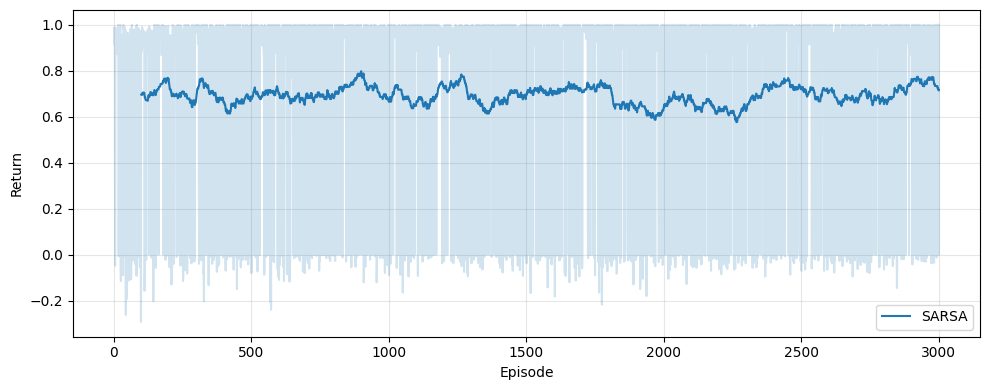

In [9]:
# Plot the training progression
plot_training_curve(sarsa_returns, label='SARSA', save_path='plots/configA_sarsa_curve_test.png')

In [10]:
# Fixed parameters based on your environment logs
N_STATES = 716
N_ACTIONS = 25
N_EPISODES = 3000

# ─── NEW TRACKERS FOR CAPTURING THE LIVE TRIALS ──────────────────────────────
best_score_tracker = -float('inf')
best_returns_tracker = None 
# ─────────────────────────────────────────────────────────────────────────────

def objective(trial):
    global best_score_tracker, best_returns_tracker
    
    # 1. Ask Optuna to suggest hyperparameters from your choices
    a = trial.suggest_categorical('alpha', [0.2, 0.1, 0.05])
    g = trial.suggest_categorical('gamma', [0.9, 0.7, 0.5, 0.3, 0.1])
    eps_start = trial.suggest_categorical('epsilon_start', [0.9, 0.7, 0.5, 0.3])
    eps_end = trial.suggest_categorical('epsilon_end', [0.01, 0.1, 0.2, 0.3])
    eps_decay = trial.suggest_categorical('epsilon_decay', [3000, 2000, 1000, 500])
    a_decay = trial.suggest_categorical('alpha_decay', ['constant', 'linear'])
    q_init = trial.suggest_categorical('q_init', [0.0, 1.0, 'random'])
    
    cfg = SARSAConfig(
        alpha=a,
        gamma=g,
        epsilon_start=eps_start,
        epsilon_end=eps_end,
        epsilon_decay=eps_decay,
        alpha_decay=a_decay,
        q_init=q_init,
        n_episodes=N_EPISODES
    )
    
    # 2. Initialize and train the agent
    agent = SARSAAgent(n_states=N_STATES, n_actions=N_ACTIONS, cfg=cfg)
    returns = agent.train(make_sepsis_env)
    
    # 3. Calculate performance score (average of the last 500 episodes)
    final_score = np.mean(returns[-500:])
    
    # ─── LIVE CAPTURE: If this trial is the best so far, capture its returns! ───
    if final_score > best_score_tracker:
        best_score_tracker = final_score
        best_returns_tracker = returns.copy()  # Capture the exact data live!
    # ─────────────────────────────────────────────────────────────────────────────
    
    return final_score

print("=== Starting Intelligent Optuna Parameter Search ===")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200) 

print("\n=== Optuna Parameter Search Complete ===")
print(f"Best Hyperparameters Found: {study.best_params}")
print(f"Max Achieved Performance Score: {study.best_value:.4f}")

[I 2026-05-29 13:41:30,784] A new study created in memory with name: no-name-506d013b-7764-4279-a729-71a727eb9cfe


=== Starting Intelligent Optuna Parameter Search ===
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-29 13:41:33,031] Trial 0 finished with value: 0.69423 and parameters: {'alpha': 0.2, 'gamma': 0.5, 'epsilon_start': 0.5, 'epsilon_end': 0.1, 'epsilon_decay': 2000, 'alpha_decay': 'constant', 'q_init': 0.0}. Best is trial 0 with value: 0.69423.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-29 13:41:36,129] Trial 1 finished with value: 0.6463600000000002 and parameters: {'alpha': 0.2, 'gamma': 0.3, 'epsilon_start': 0.3, 'epsilon_end': 0.2, 'epsilon_decay': 2000, 'alpha_decay': 'constant', 'q_init': 0.0}. Best is trial 0 with value: 0.69423.


...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-29 13:49:11,952] Trial 198 finished with value: 0.7009449999999999 and parameters: {'alpha': 0.05, 'gamma': 0.1, 'epsilon_start': 0.7, 'epsilon_end': 0.01, 'epsilon_decay': 500, 'alpha_decay': 'constant', 'q_init': 0.0}. Best is trial 85 with value: 0.7859700000000001.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-05-29 13:49:13,902] Trial 199 finished with value: 0.71689 and parameters: {'alpha': 0.2, 'gamma': 0.1, 'epsilon_start': 0.7, 'epsilon_end': 0.01, 'epsilon_decay': 1000, 'alpha_decay': 'constant', 'q_init': 0.0}. Best is trial 85 with value: 0.7859700000000001.



=== Optuna Parameter Search Complete ===
Best Hyperparameters Found: {'alpha': 0.2, 'gamma': 0.5, 'epsilon_start': 0.5, 'epsilon_end': 0.01, 'epsilon_decay': 500, 'alpha_decay': 'constant', 'q_init': 0.0}
Max Achieved Performance Score: 0.7860


<Axes: xlabel='Episode', ylabel='Return'>

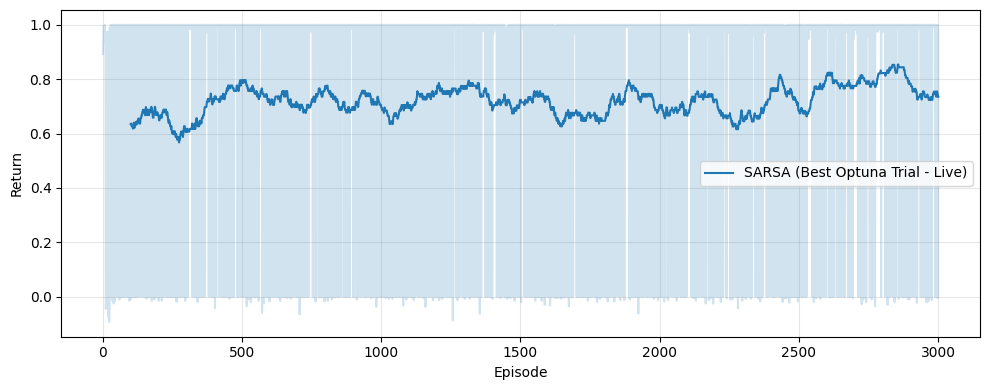

In [11]:
plot_training_curve(
    best_returns_tracker, 
    label='SARSA (Best Optuna Trial - Live)', 
    save_path='plots/configA_sarsa_curve_1.png'
)

In [12]:
optuna.visualization.plot_optimization_history(study).show()

In [13]:
optuna.visualization.plot_param_importances(study).show()

In [14]:
optuna.visualization.plot_parallel_coordinate(study).show()

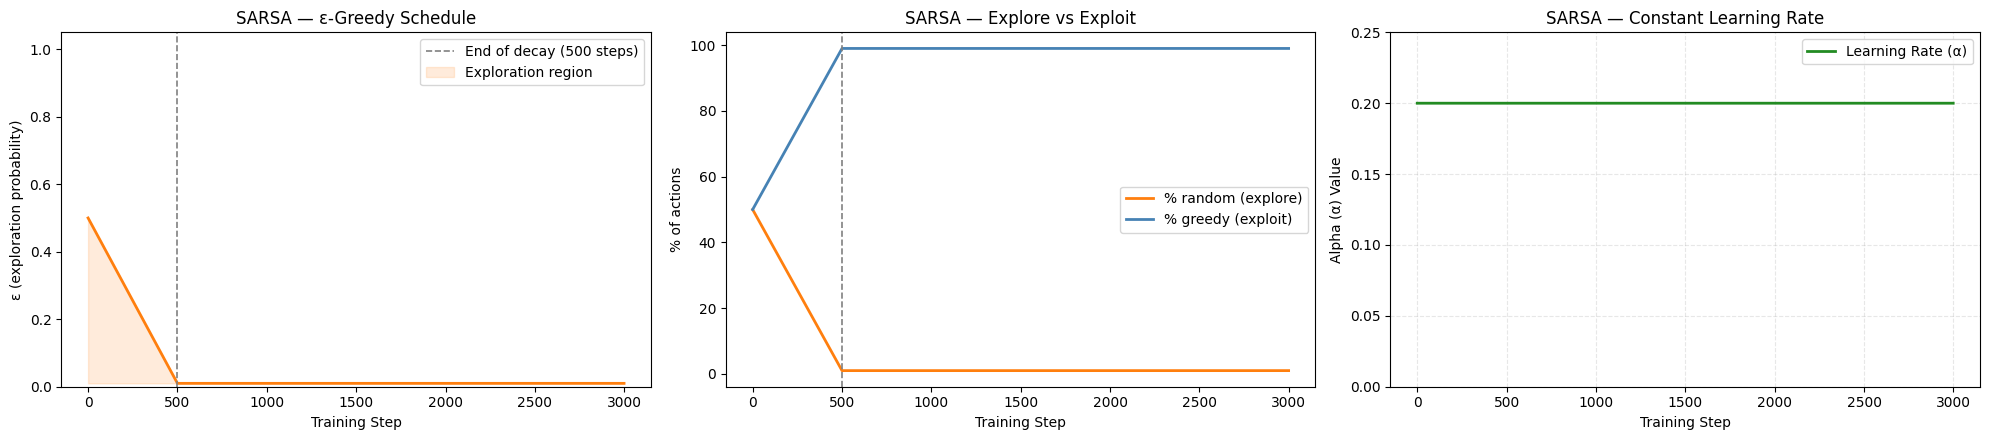

Exploration phase finishes at step 500
Final ε floor = 0.01 → 1.0% of actions remain random
Alpha strategy: 'constant' starting at α = 0.2


In [15]:
# 1. Reconstruct the step timeline based on your configuration
total_training_steps = 3000 
steps = np.arange(total_training_steps)

# Pull parameters straight from the Optuna study.best_params dictionary
best_params = study.best_params

# 2. Replicate the exact SARSA step-based linear epsilon calculation
frac_eps = np.minimum(steps / best_params['epsilon_decay'], 1.0)
epsilon = best_params['epsilon_start'] + frac_eps * (best_params['epsilon_end'] - best_params['epsilon_start'])

# 3. Replicate the dynamic alpha step-based calculation
if best_params['alpha_decay'] == 'linear':
    # Matches your class method decaying down to 0.001 over 150,000 steps
    frac_alpha = np.minimum(steps / 150000, 1.0)
    alpha_schedule = best_params['alpha'] + frac_alpha * (0.001 - best_params['alpha'])
else:
    alpha_schedule = np.full_like(steps, best_params['alpha'], dtype=float)

# 4. Create a 1x3 side-by-side plot layout to seamlessly include the Learning Rate
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))

# --- Left Plot: Epsilon Curve ---
ax = axes[0]
ax.plot(steps, epsilon, color='tab:orange', linewidth=2)
ax.axvline(best_params['epsilon_decay'], color='gray', linestyle='--', linewidth=1.2,
           label=f"End of decay ({best_params['epsilon_decay']:,} steps)")
ax.fill_between(steps, epsilon, best_params['epsilon_end'],
                alpha=0.15, color='tab:orange', label='Exploration region')
ax.set_xlabel('Training Step')
ax.set_ylabel('ε (exploration probability)')
ax.set_title('SARSA — ε-Greedy Schedule')
ax.set_ylim(0, 1.05)
ax.legend()

# --- Center Plot: Explore vs Exploit ---
ax = axes[1]
ax.plot(steps, epsilon * 100,       color='tab:orange', linewidth=2, label='% random (explore)')
ax.plot(steps, (1 - epsilon) * 100, color='steelblue',  linewidth=2, label='% greedy (exploit)')
ax.axvline(best_params['epsilon_decay'], color='gray', linestyle='--', linewidth=1.2)
ax.set_xlabel('Training Step')
ax.set_ylabel('% of actions')
ax.set_title('SARSA — Explore vs Exploit')
ax.legend()

# --- Right Plot: Learning Rate (α) Schedule ---
ax = axes[2]
ax.plot(steps, alpha_schedule, color='forestgreen', linewidth=2, label='Learning Rate (α)')
if best_params['alpha_decay'] == 'linear':
    ax.set_title('SARSA — Linear Learning Rate Decay')
else:
    ax.set_title('SARSA — Constant Learning Rate')
ax.set_xlabel('Training Step')
ax.set_ylabel('Alpha (α) Value')
ax.set_ylim(0, max(0.25, best_params['alpha'] * 1.1))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('plots/configA_sarsa_exploration_and_alpha.png', dpi=150)
plt.show()

# Print metrics context using the correct config parameters
print(f"Exploration phase finishes at step {best_params['epsilon_decay']:,}")
print(f"Final ε floor = {best_params['epsilon_end']} → {best_params['epsilon_end']:.1%} of actions remain random")
print(f"Alpha strategy: '{best_params['alpha_decay']}' starting at α = {best_params['alpha']}")